# Fuzzy Logic — Final Publication-Ready Models (LOOCV)

Single, clean implementation of the redesigned, leakage-free fuzzy inference
systems for the three targets of the study, each evaluated under leave-one-out
cross-validation (LOOCV) on the full sample (n = 18).

## 1. Introduction

This notebook implements the **redesigned fuzzy logic system** and reports its
publication-ready results. Three fuzzy inference models are built, one per target:

| Target | Approach | Membership functions | Predictors |
|---|---|---|---|
| **BMWP** prediction | **E** | Fuzzy C-Means (per fold) | Conductividad, SDT, Turbiedad |
| **Perlidae** habitat suitability | **E** | Fuzzy C-Means (per fold) | Turbiedad, DBO5, SDT |
| **Helicopsychidae** habitat suitability | **A** | Original expert (fixed) | SDT, DBO5 |

**Why the redesign was necessary.** The original fuzzy notebooks (01a–01c)
generated one rule per observation and evaluated on those same observations. The
LOOCV audit in `01d` showed this design collapses out of sample: **61 % of held-out
stations (11/18) fell into rule combinations that no training fold covered**, and
accuracy dropped to chance. The systematic search in `01e` found that the decisive
fix is **reducing the antecedent space** (fewer predictors → far higher rule
coverage), optionally combined with a **leakage-free membership-function estimator**
(Fuzzy C-Means fitted inside each fold). Approach **E** (FCM + 3 predictors) won for
BMWP and Perlidae; Approach **A** (original expert membership functions + 2
predictors) won for the rare Helicopsychidae taxon (the only low-coverage option with
a positive Cohen's κ).

**Residual leakage caveat.** Membership functions for BMWP and Perlidae are estimated
by Fuzzy C-Means **inside each LOOCV fold, on training data only**, and the inference
rules are generated **per fold** from the n−1 training rows. Neither the rules nor the
fold membership functions see the held-out station. The only design-time dependence
that remains is **predictor selection by AIC on the full sample** (done once, outside
the folds); strictly this should be nested inside the cross-validation, so a mild
optimism remains. The system is therefore *leakage-reduced to the membership-function
and rule level*, with predictor choice as the residual dependency.

## 2. Dependencies and Data Loading

All 18 observations are retained (no IQR outlier removal) so the redesigned system is
comparable with the other techniques and each LOOCV fold has the maximum training
data. The `Trichoptera` column encodes Helicopsychidae presence/absence.

In [1]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import functools, operator
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score,
                             cohen_kappa_score, confusion_matrix, classification_report,
                             mean_absolute_error, r2_score)
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [2]:
# Load both datasets in full (relative paths, no outlier removal)
macro_df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
macro_df.columns = macro_df.columns.str.strip()
bmwp_df = pd.read_excel("../../data/Database - BMWP.xlsx")
bmwp_df.columns = bmwp_df.columns.str.strip()
print("macro:", macro_df.shape, "| bmwp:", bmwp_df.shape)
print("Perlidae +/-:", macro_df['Perlidae'].value_counts().to_dict())
print("Helicopsychidae (Trichoptera) +/-:", macro_df['Trichoptera'].value_counts().to_dict())

macro: (18, 24) | bmwp: (18, 24)
Perlidae +/-: {0: 12, 1: 6}
Helicopsychidae (Trichoptera) +/-: {0: 15, 1: 3}


In [3]:
# Fixed universes and expert membership-function specifications (identical to 01e)
UNIV = {'DBO5': (0, 36, 0.1), 'OD': (0, 10.1, 0.1), 'Turbiedad': (0, 91, 0.1),
        'Conductividad': (0, 800, 1), 'SDT': (0, 800, 1)}

ORIG_MF = {
    'DBO5':          [('Bajo', 'trimf', [0, 2, 3]), ('Medio', 'trimf', [2.5, 4, 6]), ('Alto', 'trapmf', [5, 7, 36, 36])],
    'OD':            [('Bajo', 'trapmf', [0, 0, 5, 5.8]), ('Medio', 'trimf', [5.5, 6.3, 6.9]), ('Alto', 'trapmf', [6.5, 7, 10, 10])],
    'Turbiedad':     [('Baja', 'trimf', [0, 2, 5]), ('Media', 'trimf', [4, 8, 12]), ('Alta', 'trapmf', [10, 20, 91, 91])],
    'Conductividad': [('Baja', 'trimf', [50, 80, 150]), ('Media', 'trimf', [100, 250, 400]), ('Alta', 'trapmf', [300, 450, 800, 800])],
    'SDT':           [('Bajo', 'trimf', [30, 50, 70]), ('Medio', 'trimf', [60, 90, 110]), ('Alto', 'trapmf', [100, 120, 800, 800])],
}

# BMWP/Col consequent quality classes (worst to best)
BMWP_ORDER = ['Muy critica', 'Critica', 'Dudosa', 'Aceptable', 'Buena']
BMWP_CONS = {'name': 'bmwp', 'universe': (0, 121, 1), 'terms': [
    ('Muy critica', 'trimf', [0, 0, 15]), ('Critica', 'trimf', [15, 35, 35]),
    ('Dudosa', 'trimf', [36, 60, 60]), ('Aceptable', 'trimf', [61, 100, 100]),
    ('Buena', 'trimf', [101, 120, 120])]}

def bin_cons(name):
    # Presence/absence consequent for the binary habitat models
    return {'name': name, 'universe': (0, 1.1, 0.1),
            'terms': [('Ausente', 'trimf', [0, 0, 0.5]), ('Presente', 'trimf', [0.5, 1, 1])]}

In [4]:
# Membership-function builders: fixed expert MFs and per-fold Fuzzy C-Means MFs
def build_fixed(spec, universe):
    # Build a dict of label -> membership array from an expert specification
    u = np.arange(*universe)
    return {lab: getattr(fuzz, kind)(u, par) for lab, kind, par in spec}

def shoulder_terms(universe, peaks):
    # Three value-sorted fuzzy sets (Low/Medium/High) with shoulders spanning the universe
    u = np.arange(*universe)
    umin, umax = float(u[0]), float(u[-1])
    p = sorted(min(max(float(x), umin), umax) for x in peaks)
    eps = (umax - umin) * 1e-3
    if not p[0] < p[1]: p[1] = min(p[0] + eps, umax)
    if not p[1] < p[2]: p[2] = min(p[1] + eps, umax)
    return {'Low': fuzz.trapmf(u, [umin, umin, p[0], p[1]]),
            'Medium': fuzz.trimf(u, [p[0], p[1], p[2]]),
            'High': fuzz.trapmf(u, [p[1], p[2], umax, umax])}

def fcm_terms(train, predictors, c=3, m=2):
    # Fuzzy C-Means on TRAINING predictors only; cluster centroids become MF peaks
    data = train[predictors].values.T.astype(float)
    cntr, *_ = fuzz.cluster.cmeans(data, c=c, m=m, error=0.005, maxiter=1000, init=None, seed=0)
    return {p: shoulder_terms(UNIV[p], sorted(cntr[:, j])) for j, p in enumerate(predictors)}

def make_fold_mf(mf_type):
    # Return a per-fold MF factory: 'orig' (fixed expert) or 'fcm' (data-driven)
    if mf_type == 'orig':
        return lambda train, preds: {p: build_fixed(ORIG_MF[p], UNIV[p]) for p in preds}
    if mf_type == 'fcm':
        return lambda train, preds: fcm_terms(train, preds)
    raise ValueError(mf_type)

def cat_label(value, variable):
    # Crisp value -> highest-membership linguistic label for a fuzzy variable
    deg = {lab: fuzz.interp_membership(variable.universe, variable[lab].mf, value) for lab in variable.terms}
    return max(deg, key=deg.get)

In [5]:
# Leave-one-out engine: rules built from the n-1 training rows only, held-out row predicted
def run_loocv(df, response, predictors, fold_mf, cons_spec, is_bmwp, threshold=0.5, verbose=False):
    loo = LeaveOneOut()
    y_true, y_pred, failed, crisp_ok, num_ok, succ_idx = [], [], [], [], [], []
    for fold, (tr, te) in enumerate(loo.split(df)):
        if verbose:
            print(f"{fold+1}", end=' ', flush=True)
        train = df.iloc[tr]; test = df.iloc[te].iloc[0]
        terms = fold_mf(train, predictors)
        antecedents = {}
        for p in predictors:
            a = ctrl.Antecedent(np.arange(*UNIV[p]), p)
            for lab, arr in terms[p].items():
                a[lab] = arr
            antecedents[p] = a
        cons = ctrl.Consequent(np.arange(*cons_spec['universe']), cons_spec['name'])
        for lab, kind, par in cons_spec['terms']:
            cons[lab] = getattr(fuzz, kind)(cons.universe, par)
        rules = []
        for _, row in train.iterrows():
            ante = functools.reduce(operator.and_,
                                    [antecedents[p][cat_label(row[p], antecedents[p])] for p in predictors])
            ct = cons[cat_label(row['BMWP'], cons)] if is_bmwp else (
                cons['Presente'] if row[response] == 1 else cons['Ausente'])
            rules.append(ctrl.Rule(ante, ct))
        sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
        true_lbl = cat_label(test['BMWP'], cons) if is_bmwp else (
            'Presente' if test[response] == 1 else 'Ausente')
        try:
            for p in predictors:
                sim.input[p] = float(test[p])
            sim.compute()
            out = sim.output[cons_spec['name']]
            pred_lbl = cat_label(out, cons) if is_bmwp else ('Presente' if out >= threshold else 'Ausente')
            y_pred.append(pred_lbl); y_true.append(true_lbl); crisp_ok.append(out); succ_idx.append(fold)
            if is_bmwp:
                num_ok.append(float(test['BMWP']))
        except Exception:
            failed.append(fold); y_pred.append('No coverage'); y_true.append(true_lbl)
    if verbose:
        print("done.")
    return {'y_true': y_true, 'y_pred': y_pred, 'failed': failed,
            'crisp_ok': crisp_ok, 'num_ok': num_ok, 'succ_idx': succ_idx}

def compute_metrics(y_true, y_pred, real_classes):
    # Macro precision/recall/F1, accuracy and Cohen's kappa for a set of predictions
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=real_classes,
                                                 average='macro', zero_division=0)
    try:
        kappa = cohen_kappa_score(y_true, y_pred)
    except Exception:
        kappa = float('nan')
    return {'precision': p, 'recall': r, 'f1': f,
            'accuracy': accuracy_score(y_true, y_pred), 'kappa': kappa}

In [6]:
# Standardised confusion-matrix plotter: figsize (10, 7), Blues, saved to outputs/ and shown
def plot_confusion(y_true, y_pred, labels, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
                xticklabels=labels, yticklabels=labels, cbar=True)
    plt.title(title, fontsize=14)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Observed', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"../../outputs/{filename}", dpi=300)
    plt.show()

## 3. Predictor Selection

Predictors were chosen in `01e` by ranking the five physicochemical variables by
univariate AIC and keeping the 2–3 strongest for each target. Reducing the antecedent
space is what restores out-of-sample rule coverage. The selections are fixed below.

In [7]:
# Selected predictors per target (top 2-3 by univariate AIC; fixed from 01e)
bmwp_pred = ['Conductividad', 'SDT', 'Turbiedad']   # BMWP        - Approach E
perlidae_pred = ['Turbiedad', 'DBO5', 'SDT']        # Perlidae    - Approach E
helico_pred = ['SDT', 'DBO5']                       # Helico.     - Approach A
print("BMWP predictors           :", bmwp_pred)
print("Perlidae predictors       :", perlidae_pred)
print("Helicopsychidae predictors:", helico_pred)

BMWP predictors           : ['Conductividad', 'SDT', 'Turbiedad']
Perlidae predictors       : ['Turbiedad', 'DBO5', 'SDT']
Helicopsychidae predictors: ['SDT', 'DBO5']


## 4. Model Definition

Each model is defined by its dataset, response column, predictor set, per-fold
membership-function factory and consequent. BMWP and Perlidae use data-driven Fuzzy
C-Means membership functions (`fcm`); Helicopsychidae uses the fixed expert
membership functions (`orig`).

In [8]:
# Model registry: (dataframe, response, predictors, MF factory, consequent spec, is_bmwp)
models = {
    'BMWP':            dict(df=bmwp_df,  response='BMWP',        predictors=bmwp_pred,
                            fold_mf=make_fold_mf('fcm'),  cons=BMWP_CONS,             is_bmwp=True),
    'Perlidae':        dict(df=macro_df, response='Perlidae',    predictors=perlidae_pred,
                            fold_mf=make_fold_mf('fcm'),  cons=bin_cons('Perlidae'),  is_bmwp=False),
    'Helicopsychidae': dict(df=macro_df, response='Trichoptera', predictors=helico_pred,
                            fold_mf=make_fold_mf('orig'), cons=bin_cons('Trichoptera'), is_bmwp=False),
}
print("Defined models:", list(models.keys()))

Defined models: ['BMWP', 'Perlidae', 'Helicopsychidae']


## 5. Calibration

In the LOOCV framework used here, each fold trains on n-1 observations
and evaluates on 1 held-out observation. Unlike traditional train/test
splits, there is no fixed calibration set — the training data changes
in each fold. Calibration-equivalent metrics can be approximated by
aggregating training-fold predictions across all folds, but these
are not reported here as they would still reflect near-in-sample
performance given the rule-data dependency. Validation metrics
(Section 6) are the primary performance evidence for this system.

## 6. Evaluation — Validation (LOOCV)

Each model is evaluated by leave-one-out cross-validation. For every model we report
the validation confusion matrix (saved to `outputs/`), the classification report,
Cohen's κ and the number of coverage failures (held-out stations whose predictor
combination matched no training rule, counted as incorrect). For BMWP we additionally
report the numerical metrics in Section 7.

In [9]:
# Run LOOCV for all three models
results = {}
for name, cfg in models.items():
    print(f"{name} LOOCV folds:", end=' ')
    res = run_loocv(cfg['df'], cfg['response'], cfg['predictors'], cfg['fold_mf'],
                    cfg['cons'], is_bmwp=cfg['is_bmwp'], verbose=True)
    results[name] = res

BMWP LOOCV folds: 1 

2 

3 

4 

5 

...

15 

16 

17 

18 

done.


### 6.1 BMWP model

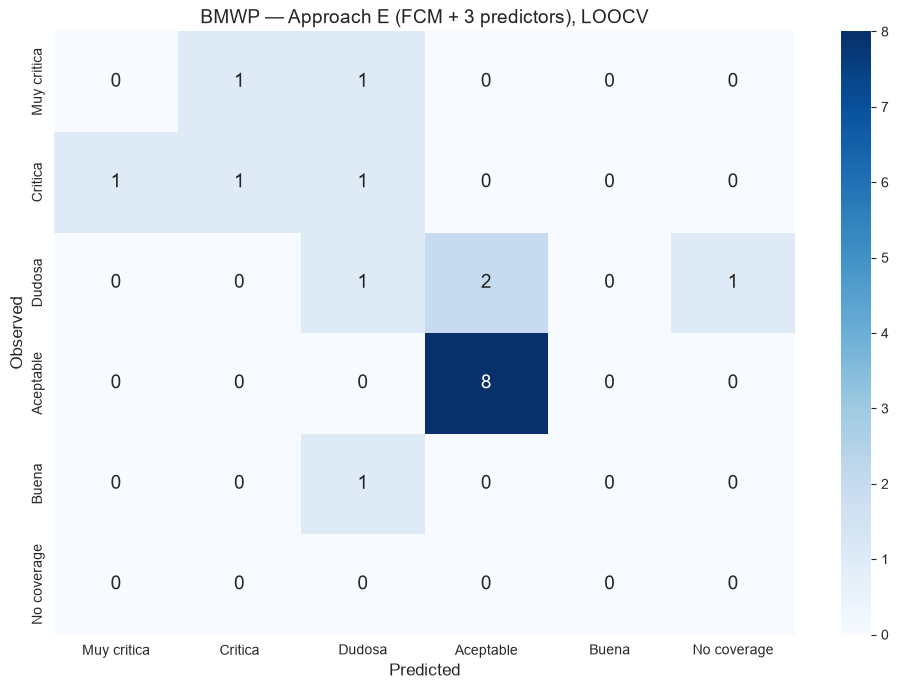

              precision    recall  f1-score   support

 Muy critica       0.00      0.00      0.00         2
     Critica       0.50      0.33      0.40         3
      Dudosa       0.25      0.25      0.25         4
   Aceptable       0.80      1.00      0.89         8
       Buena       0.00      0.00      0.00         1
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.56        18
   macro avg       0.26      0.26      0.26        18
weighted avg       0.49      0.56      0.52        18

Cohen's Kappa: 0.345
Coverage failures: 1 of 18 folds


In [10]:
# BMWP validation: confusion matrix, classification report, Cohen's kappa, coverage failures
res = results['BMWP']
bmwp_classes = [cl for cl in BMWP_ORDER if cl in res['y_true']]
bmwp_labels = bmwp_classes + (['No coverage'] if 'No coverage' in res['y_pred'] else [])
plot_confusion(res['y_true'], res['y_pred'], bmwp_labels,
               'BMWP — Approach E (FCM + 3 predictors), LOOCV',
               'fuzzy_bmwp_confusion_matrix_validation.png')
print(classification_report(res['y_true'], res['y_pred'], labels=bmwp_labels, zero_division=0))
bmwp_m = compute_metrics(res['y_true'], res['y_pred'], bmwp_classes)
print(f"Cohen's Kappa: {bmwp_m['kappa']:.3f}")
print(f"Coverage failures: {len(res['failed'])} of 18 folds")

### 6.2 Perlidae model

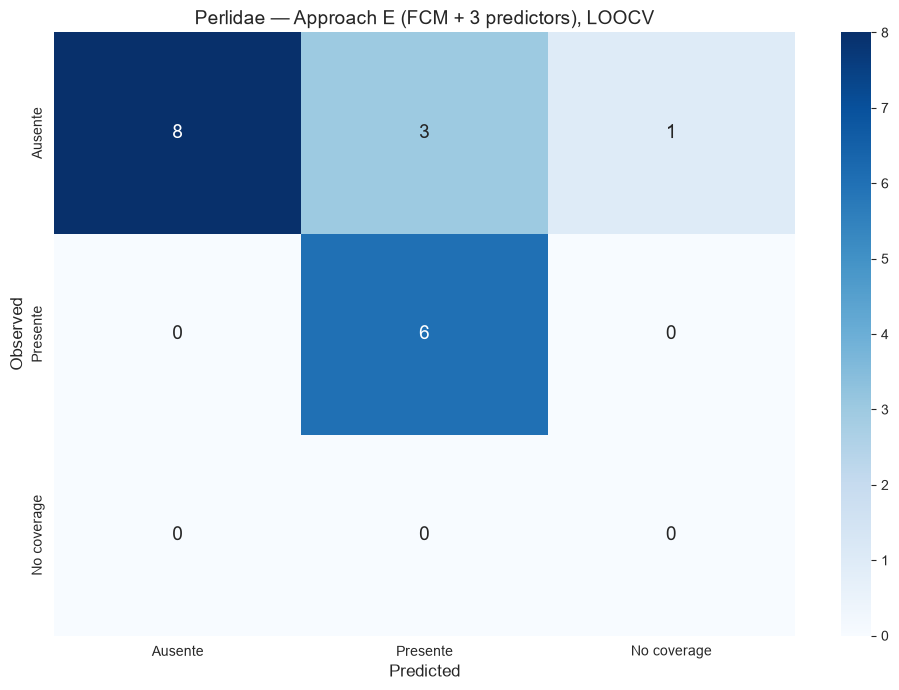

              precision    recall  f1-score   support

     Ausente       1.00      0.67      0.80        12
    Presente       0.67      1.00      0.80         6
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.78        18
   macro avg       0.56      0.56      0.53        18
weighted avg       0.89      0.78      0.80        18

Cohen's Kappa: 0.586
Coverage failures: 1 of 18 folds


In [11]:
# Perlidae validation: confusion matrix, classification report, Cohen's kappa, coverage failures
res = results['Perlidae']
perl_labels = ['Ausente', 'Presente'] + (['No coverage'] if 'No coverage' in res['y_pred'] else [])
plot_confusion(res['y_true'], res['y_pred'], perl_labels,
               'Perlidae — Approach E (FCM + 3 predictors), LOOCV',
               'fuzzy_perlidae_confusion_matrix_validation.png')
print(classification_report(res['y_true'], res['y_pred'], labels=perl_labels, zero_division=0))
perl_m = compute_metrics(res['y_true'], res['y_pred'], ['Ausente', 'Presente'])
print(f"Cohen's Kappa: {perl_m['kappa']:.3f}")
print(f"Coverage failures: {len(res['failed'])} of 18 folds")

### 6.3 Helicopsychidae model

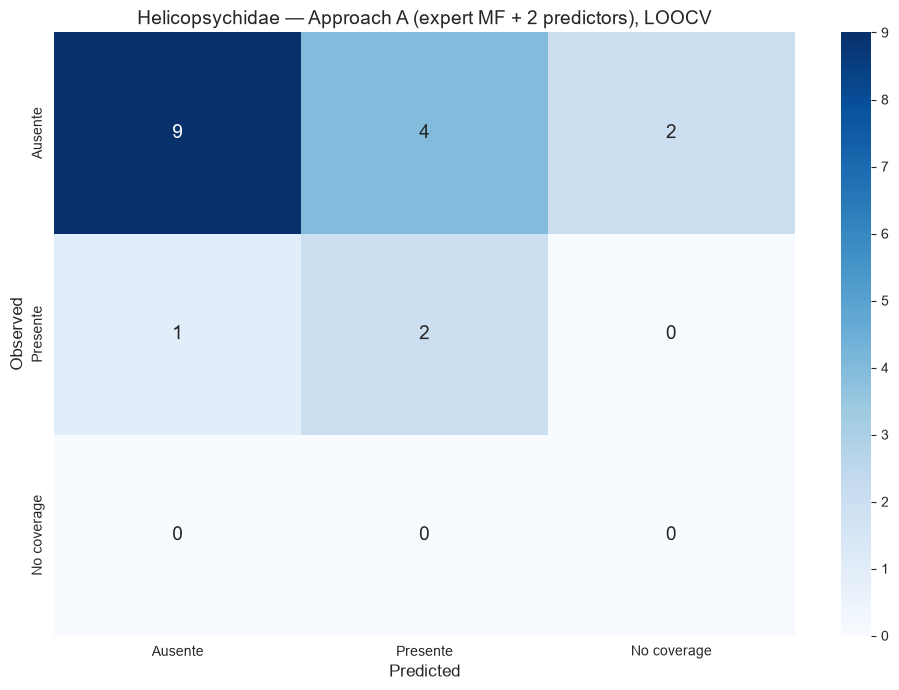

              precision    recall  f1-score   support

     Ausente       0.90      0.60      0.72        15
    Presente       0.33      0.67      0.44         3
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.61        18
   macro avg       0.41      0.42      0.39        18
weighted avg       0.81      0.61      0.67        18

Cohen's Kappa: 0.192
Coverage failures: 2 of 18 folds


In [12]:
# Helicopsychidae validation: confusion matrix, classification report, Cohen's kappa, coverage failures
res = results['Helicopsychidae']
heli_labels = ['Ausente', 'Presente'] + (['No coverage'] if 'No coverage' in res['y_pred'] else [])
plot_confusion(res['y_true'], res['y_pred'], heli_labels,
               'Helicopsychidae — Approach A (expert MF + 2 predictors), LOOCV',
               'fuzzy_helicopsychidae_confusion_matrix_validation.png')
print(classification_report(res['y_true'], res['y_pred'], labels=heli_labels, zero_division=0))
heli_m = compute_metrics(res['y_true'], res['y_pred'], ['Ausente', 'Presente'])
print(f"Cohen's Kappa: {heli_m['kappa']:.3f}")
print(f"Coverage failures: {len(res['failed'])} of 18 folds")

In [13]:
# Assemble the redesigned-fuzzy metric summary and export it in the shared schema
def r3(x):
    return round(float(x), 3)

summary = pd.DataFrame([
    {'target': 'BMWP', 'technique': 'Fuzzy logic (redesigned)', 'validation': 'LOOCV', 'n': 18,
     'precision': r3(bmwp_m['precision']), 'recall': r3(bmwp_m['recall']), 'f1': r3(bmwp_m['f1']),
     'accuracy': r3(bmwp_m['accuracy']), 'kappa': r3(bmwp_m['kappa'])},
    {'target': 'Perlidae', 'technique': 'Fuzzy logic (redesigned)', 'validation': 'LOOCV', 'n': 18,
     'precision': r3(perl_m['precision']), 'recall': r3(perl_m['recall']), 'f1': r3(perl_m['f1']),
     'accuracy': r3(perl_m['accuracy']), 'kappa': r3(perl_m['kappa'])},
    {'target': 'Helicopsychidae', 'technique': 'Fuzzy logic (redesigned)', 'validation': 'LOOCV', 'n': 18,
     'precision': r3(heli_m['precision']), 'recall': r3(heli_m['recall']), 'f1': r3(heli_m['f1']),
     'accuracy': r3(heli_m['accuracy']), 'kappa': r3(heli_m['kappa'])},
])
summary.to_csv("../../outputs/metrics_fuzzy_redesigned.csv", index=False)
print("Saved outputs/metrics_fuzzy_redesigned.csv")
display(summary)

Saved outputs/metrics_fuzzy_redesigned.csv


,target,technique,validation,n,precision,recall,f1,accuracy,kappa
0,BMWP,Fuzzy logic (redesigned),LOOCV,18,0.310,0.317,0.308,0.556,0.345
1,Perlidae,Fuzzy logic (redesigned),LOOCV,18,0.833,0.833,0.800,0.778,0.586
2,Helicopsychidae,Fuzzy logic (redesigned),LOOCV,18,0.617,0.633,0.582,0.611,0.192


## 7. Numerical Performance (BMWP only)

Numerical accuracy of the crisp (defuzzified) BMWP predictions against the observed
BMWP/Col index, computed over the successful folds only (coverage failures produce no
crisp output and are excluded). MAE and RMSE are on the 0–120 BMWP/Col scale.

In [14]:
# BMWP numerical metrics on the crisp defuzzified output (successful folds only)
res = results['BMWP']
y_obs = np.array(res['num_ok'])
y_hat = np.array(res['crisp_ok'])
n_ok = len(y_hat)

mae = mean_absolute_error(y_obs, y_hat)
rmse = float(np.sqrt(np.mean((y_obs - y_hat) ** 2)))
r2 = r2_score(y_obs, y_hat)
rs, p = spearmanr(y_obs, y_hat)

print(f"=== BMWP Numerical Performance (LOOCV, n={n_ok} successful folds) ===")
print(f"MAE:  {mae:.2f} BMWP points")
print(f"RMSE: {rmse:.2f} BMWP points")
print(f"R²:   {r2:.3f}")
print(f"Spearman rs: {rs:.3f} (p = {p:.4f})")
print(f"Interpretation: on average, the model's BMWP predictions deviate")
print(f"by {mae:.2f} points from the observed values on the BMWP/Col scale (0-120).")

=== BMWP Numerical Performance (LOOCV, n=17 successful folds) ===
MAE:  21.27 BMWP points
RMSE: 26.19 BMWP points
R²:   0.324
Spearman rs: 0.533 (p = 0.0274)
Interpretation: on average, the model's BMWP predictions deviate
by 21.27 points from the observed values on the BMWP/Col scale (0-120).


In [15]:
# Persist per-fold predictions and numerical metrics for notebook 05 and the master table
station_col = 'Estación' if 'Estación' in bmwp_df.columns else bmwp_df.columns[0]
bmwp_loocv_pred = pd.DataFrame({
    'Station': [bmwp_df.iloc[i][station_col] for i in res['succ_idx']],
    'Observed_BMWP': res['num_ok'],
    'Predicted_BMWP': res['crisp_ok'],
})
bmwp_loocv_pred.to_csv("../../outputs/fuzzy_final_bmwp_loocv_predictions.csv", index=False)

pd.DataFrame([{'model': 'Fuzzy redesigned', 'validation': 'LOOCV', 'n': n_ok,
               'mae': round(mae, 2), 'rmse': round(rmse, 2), 'r2': round(r2, 3),
               'rs': round(rs, 3), 'p_value': round(p, 4)}]
             ).to_csv("../../outputs/numerical_bmwp_fuzzy.csv", index=False)

pd.DataFrame([
    {'system': 'Fuzzy logic (original)', 'evaluation': 'In-sample', 'n': 14, 'rs': 0.827, 'p_value': 0.000265},
    {'system': 'Fuzzy logic (redesigned)', 'evaluation': 'LOOCV', 'n': n_ok, 'rs': round(rs, 3), 'p_value': p},
]).to_csv("../../outputs/spearman_comparison.csv", index=False)
print("Saved fuzzy_final_bmwp_loocv_predictions.csv, numerical_bmwp_fuzzy.csv, spearman_comparison.csv")

Saved fuzzy_final_bmwp_loocv_predictions.csv, numerical_bmwp_fuzzy.csv, spearman_comparison.csv

## 8. Visualisation

Two visual diagnostics are produced and saved to `outputs/`:

1. **Membership-function curves** for each predictor of each model (Low/Medium/High
   sets). For BMWP and Perlidae the curves are derived from a Fuzzy C-Means fit on the
   **full dataset for illustration only** — the LOOCV models refit FCM per fold.
   Helicopsychidae uses the fixed expert membership functions.
2. **Observed vs predicted BMWP** scatter (LOOCV crisp output) with a 1:1 reference
   line, BMWP/Col quality-band backgrounds and station labels.

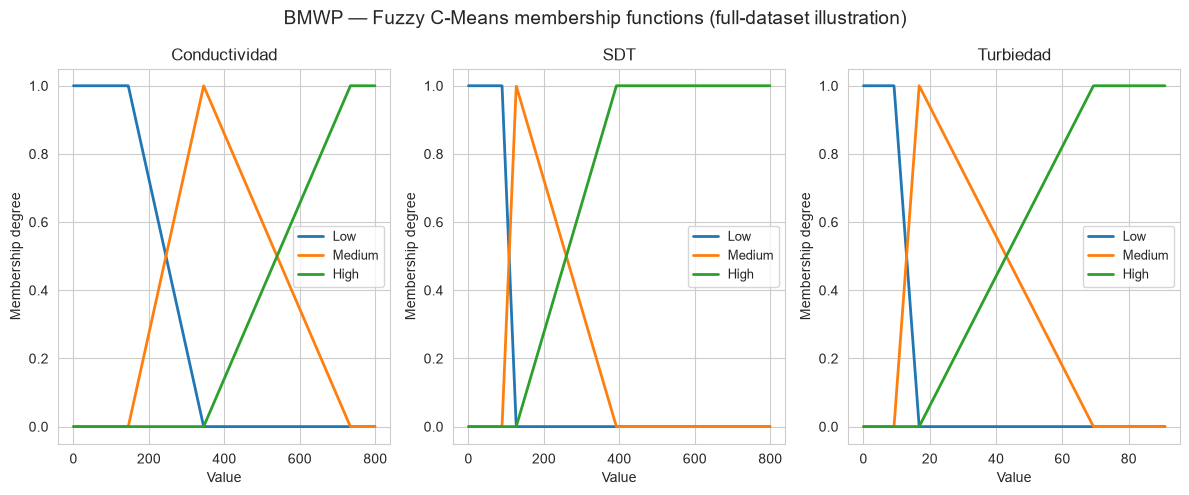

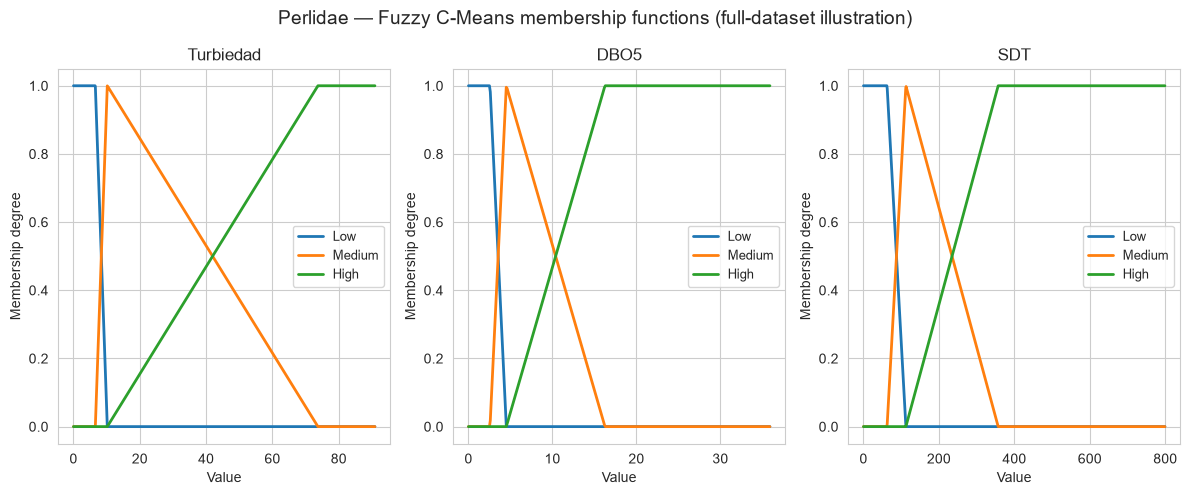

In [16]:
# Helper: plot Low/Medium/High membership functions, one subplot per predictor
def plot_membership(term_dict, predictors, title, filename):
    n = len(predictors)
    fig, axes = plt.subplots(1, n, figsize=(12, 5))
    if n == 1:
        axes = [axes]
    for ax, p in zip(axes, predictors):
        u = np.arange(*UNIV[p])
        for lab, arr in term_dict[p].items():
            ax.plot(u, arr, linewidth=2, label=lab)
        ax.set_title(p)
        ax.set_xlabel('Value')
        ax.set_ylabel('Membership degree')
        ax.legend(fontsize=9)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"../../outputs/{filename}", dpi=300)
    plt.show()

# BMWP and Perlidae: illustrative full-dataset FCM membership functions
plot_membership(fcm_terms(bmwp_df, bmwp_pred), bmwp_pred,
                'BMWP — Fuzzy C-Means membership functions (full-dataset illustration)',
                'fuzzy_membership_functions_bmwp.png')
plot_membership(fcm_terms(macro_df, perlidae_pred), perlidae_pred,
                'Perlidae — Fuzzy C-Means membership functions (full-dataset illustration)',
                'fuzzy_membership_functions_perlidae.png')

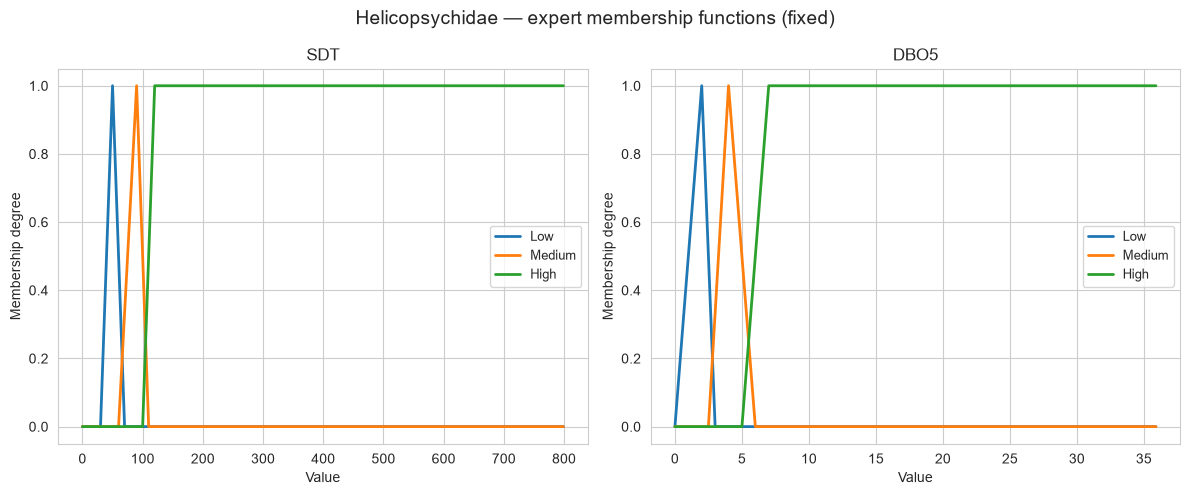

In [17]:
# Helicopsychidae: fixed expert membership functions (labels translated to English)
TR = {'Bajo': 'Low', 'Medio': 'Medium', 'Alto': 'High',
      'Baja': 'Low', 'Media': 'Medium', 'Alta': 'High'}
heli_terms = {p: {TR.get(lab, lab): arr for lab, arr in build_fixed(ORIG_MF[p], UNIV[p]).items()}
              for p in helico_pred}
plot_membership(heli_terms, helico_pred,
                'Helicopsychidae — expert membership functions (fixed)',
                'fuzzy_membership_functions_helicopsychidae.png')

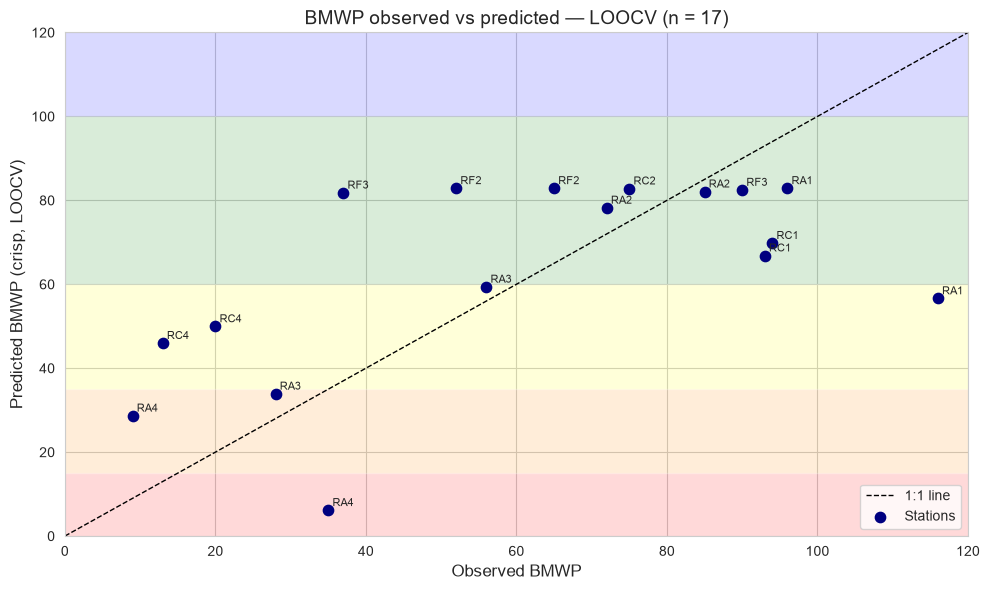

In [18]:
# Observed vs predicted BMWP scatter (LOOCV) with 1:1 line and quality-band backgrounds
res = results['BMWP']
obs = np.array(res['num_ok'])
pred = np.array(res['crisp_ok'])
stations = [bmwp_df.iloc[i][station_col] for i in res['succ_idx']]
bands = [(0, 15, 'red'), (15, 35, 'darkorange'), (35, 60, 'yellow'),
         (60, 100, 'green'), (100, 120, 'blue')]

plt.figure(figsize=(10, 6))
for lo, hi, col in bands:
    plt.axhspan(lo, hi, facecolor=col, alpha=0.15)
plt.plot([0, 120], [0, 120], 'k--', linewidth=1, label='1:1 line')
plt.scatter(obs, pred, color='navy', s=55, zorder=3, label='Stations')
for x, y, lab in zip(obs, pred, stations):
    plt.annotate(str(lab), (x, y), fontsize=8, xytext=(3, 3), textcoords='offset points')
plt.xlim(0, 120); plt.ylim(0, 120)
plt.xlabel('Observed BMWP', fontsize=12)
plt.ylabel('Predicted BMWP (crisp, LOOCV)', fontsize=12)
plt.title(f'BMWP observed vs predicted — LOOCV (n = {len(obs)})', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../../outputs/fuzzy_bmwp_observed_vs_predicted_loocv.png", dpi=300)
plt.show()

## 9. Limitations

- **Membership-function estimation (residual leakage).** Fuzzy C-Means is fitted
  **inside each LOOCV fold, on training data only** (BMWP, Perlidae), so the
  membership functions never see the held-out station; Helicopsychidae uses fixed
  expert MFs, likewise independent of the evaluation data. The only design-time
  dependence that remains is **predictor selection by AIC on the full sample** (done
  once, outside the folds), so a mild optimism remains.
- **Spatial non-independence.** Stations lie along a single river; upstream/downstream
  samples share water masses, violating the independence LOOCV assumes. Blocked /
  spatial cross-validation would be stricter but is infeasible at n = 18.
- **Small sample.** With 18 observations (Helicopsychidae: 3 presences; BMWP 'Buena':
  1 station) every metric has wide uncertainty and a single fold can move a score.
- **Coverage failures.** A 'No coverage' fold means the held-out station's predictor
  combination matched no training rule — ecologically, a site whose conditions are
  unlike anything in the training set. They are counted as incorrect; the reduced
  antecedent sets keep them rare (0–2 of 18 here versus 11 of 18 in the original
  design).